In [1]:
import os
import glob
import torch
torch.set_default_dtype(torch.double)

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)

size = 28
batch_size = 128

In [2]:
H = W = size
mnist_mean = 0.1307
mnist_var = 0.3081
train_val_split = 0.8
sigma = 0.01

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(train_val_split * len(full_dataset))
val_size = len(full_dataset) - train_size
data_train, data_val = random_split(full_dataset, [train_size, val_size])


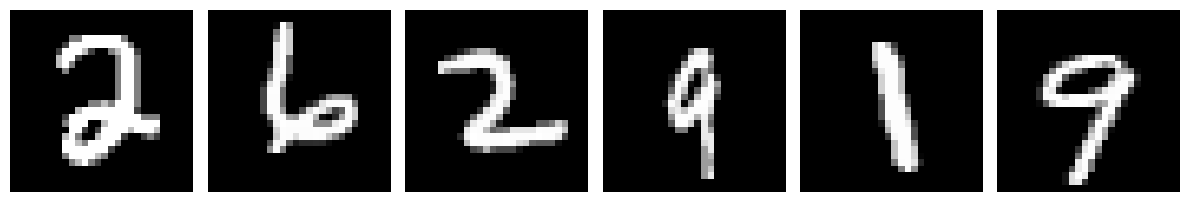

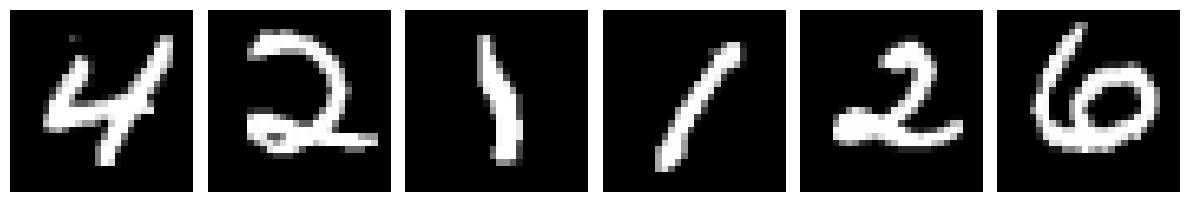

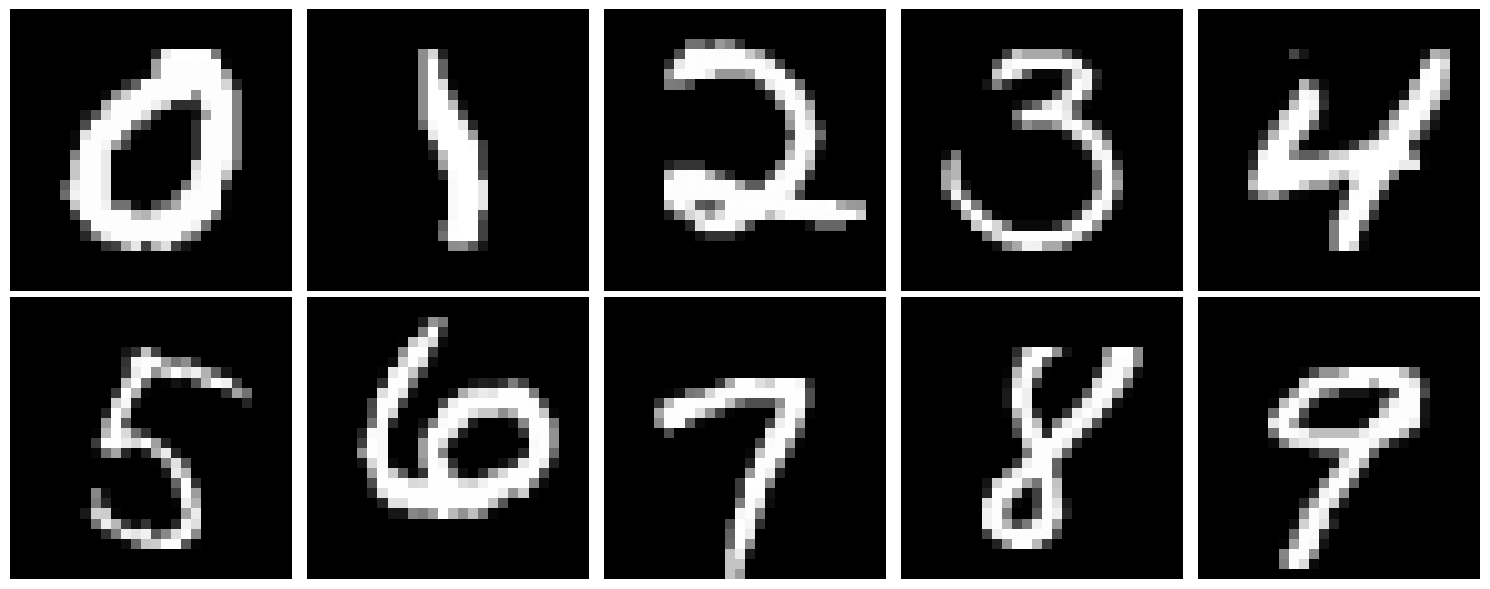

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Shape of z: torch.Size([128, 16, 7, 7])


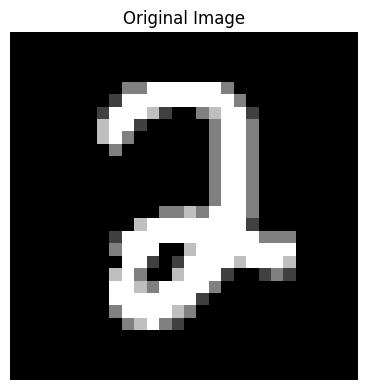

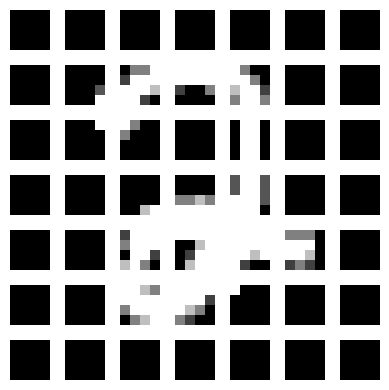

In [ ]:
from nflows import transforms

squeeze = transforms.SqueezeTransform(factor=4)

z, log_det = squeeze(train_images, context=None)     # forward
print("Shape of z:", z.shape)
x_rec, log_det_inv = squeeze.inverse(z)   # inverse

# Figure 1: original image
plt.figure(figsize=(4, 4))
plt.imshow(train_images[0].squeeze().cpu().numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()

fig, axes = plt.subplots(7, 7, figsize=(4, 4))
axes = axes.flatten()
for i in range(7):
    for j in range(7):
        axes[i*7 + j].imshow(z[0, :, i, j].reshape(4, 4), cmap='gray')
        axes[i*7 + j].axis('off')

plt.tight_layout()
plt.show()


In [13]:
print(transforms.SqueezeTransform(2).get_output_shape(1, 28, 28))

(4, 14, 14)
